# Task 03 - Data Preprocessing and Feature Engineering


### Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### Load the dataset

In [2]:
df = pd.read_csv('smartcare_ai_dataset_1000.csv')
print('Original shape:', df.shape)
display(df.head())

Original shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,4/10/2025,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,5/15/2025,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,7/9/2025,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,10/16/2025,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,12/18/2025,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


The original dataset contains 1,000 records and 33 columns. The target is `no_show`, where 1 represents a no-show and 0 represents the negative class.

## 3.1 Missing Value Handling

In [3]:
missing = df.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False).to_frame('Missing Values'))

,Missing Values
room_type,906


**Observation:** Missing values occur mainly in `room_type`. A patient who was not admitted would not have a room. However, room information is recorded after the appointment and is not available when a no-show prediction is required.

**Justification:** `room_type` and the other post-appointment variables are removed during data cleaning. Imputing these values would add no useful booking-time information and could introduce artificial data.

## 3.2 Duplicate Record Detection

In [4]:
print('Full duplicate rows:', df.duplicated().sum())
print('Duplicate record IDs:', df['record_id'].duplicated().sum())
print('Duplicate patient IDs:', df['patient_id'].duplicated().sum())

Full duplicate rows: 0
Duplicate record IDs: 0
Duplicate patient IDs: 0


**Observation:** No duplicate rows, record IDs, or patient IDs were found.

**Justification:** No records were removed because every record is unique.

## 3.3 Outlier Identification

In [5]:
numeric_check = ['age','waiting_days','previous_appointments',
                 'missed_previous_appointments','previous_admissions']

outlier_counts = {}
for column in numeric_check:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_counts[column] = ((df[column] < q1-1.5*iqr) |
                              (df[column] > q3+1.5*iqr)).sum()

display(pd.Series(outlier_counts, name='IQR Outliers').to_frame())
display(df[numeric_check].agg(['min','max']))

,IQR Outliers
age,0
waiting_days,0
previous_appointments,8
missed_previous_appointments,17
previous_admissions,60


,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions
min,1,0,0,0,0
max,90,44,10,4,5


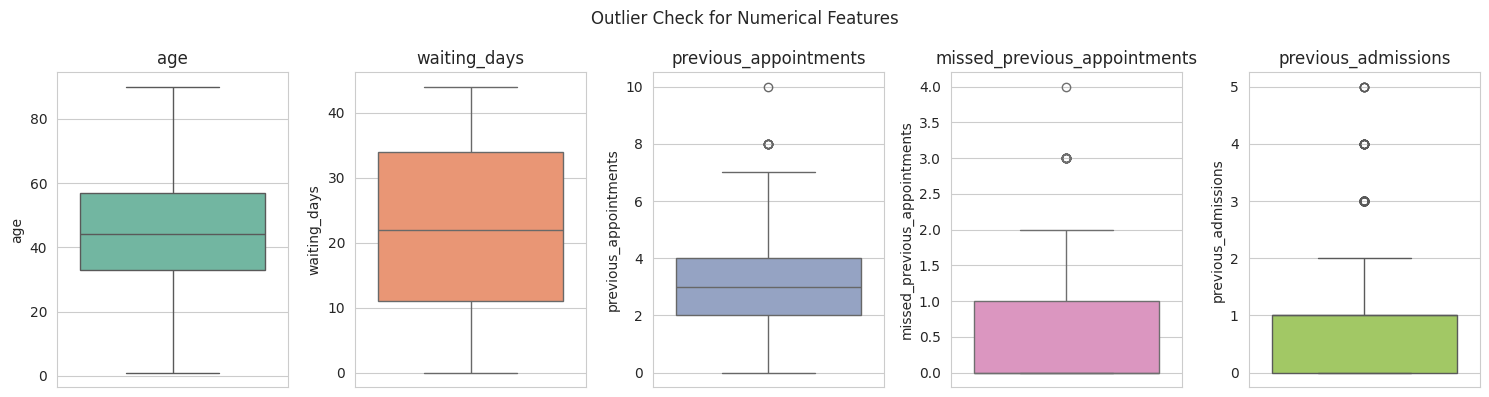

In [6]:
colors = sns.color_palette('Set2', len(numeric_check))
fig, axes = plt.subplots(1, 5, figsize=(15,4))
for column, axis, color in zip(numeric_check, axes, colors):
    sns.boxplot(y=df[column], ax=axis, color=color)
    axis.set_title(column)
plt.suptitle('Outlier Check for Numerical Features')
plt.tight_layout()
plt.show()

**Observation:** The IQR method identifies some high values in appointment and admission history. The minimum and maximum values are still realistic and no impossible negative values are present.

**Justification:** The flagged values are retained because they represent possible patient histories, not confirmed data-entry errors. Removing them could remove useful behavioural information.

## 3.4 Data Cleaning and Target Correction

In [7]:
display(pd.crosstab(df['appointment_status'], df['no_show']))

# Use only appointments with confirmed outcomes.
df_clean = df[df['appointment_status'].isin(['Completed','No-Show'])].copy()
df_clean['no_show'] = (df_clean['appointment_status'] == 'No-Show').astype(int)

print('Shape after target correction:', df_clean.shape)
print('Removed Scheduled and Cancelled records:', len(df) - len(df_clean))
display(df_clean['no_show'].value_counts().sort_index().to_frame('Count'))

no_show,0,1
appointment_status,,
Cancelled,53,0
Completed,380,0
No-Show,0,495
Scheduled,72,0


Shape after target correction: (875, 33)
Removed Scheduled and Cancelled records: 125


,Count
no_show,
0,380
1,495


**Observation:** Class 0 originally included completed, cancelled, and still-scheduled appointments. Cancelled appointments are not the same as attendance, and scheduled appointments do not yet have a confirmed outcome.

**Justification:** Only `Completed` and `No-Show` records are kept. This reduces label noise and creates a valid binary target: attended versus no-show.

In [8]:
drop_columns = [
    'record_id','patient_id','appointment_status','gender','blood_group',
    'admitted','room_type','length_of_stay_days','systolic_bp','diastolic_bp',
    'blood_sugar_mg_dl','cholesterol_mg_dl','bmi','lab_tests_count',
    'treatments_count','consultation_fee_lkr','room_charge_lkr','lab_charge_lkr',
    'medicine_charge_lkr','total_bill_lkr','payment_status','payment_method',
    'readmitted_30_days','disease_risk_level'
]

df_model = df_clean.drop(columns=drop_columns)
print('Columns retained:', df_model.columns.tolist())

Columns retained: ['age', 'department', 'diagnosis', 'appointment_date', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'no_show']


**Justification:** IDs do not describe patient behaviour. `appointment_status` directly reveals the target and would cause target leakage. Clinical, admission, treatment, and billing details are recorded after the appointment, so they cannot be used for a prediction made at booking time. Gender and blood group are excluded from model inputs because they show weak direct value and may create unnecessary fairness concerns.

## 3.5 Feature Encoding

In [9]:
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
df_model['appointment_month'] = df_model['appointment_date'].dt.month
df_model['appointment_dayofweek'] = df_model['appointment_date'].dt.dayofweek
df_model = df_model.drop(columns='appointment_date')

df_model = pd.get_dummies(df_model,
                          columns=['department','diagnosis'],
                          drop_first=True, dtype=int)
print('Shape after encoding:', df_model.shape)

Shape after encoding: (875, 23)


**Observation:** `department` and `diagnosis` are text categories without a natural order. The appointment date cannot be used directly by machine-learning models.

**Justification:** Month and weekday are extracted from the date. One-hot encoding is used for department and diagnosis because it converts categories to numbers without creating a false ranking. `drop_first=True` avoids redundant dummy columns.

## 3.6 Feature Engineering

In [10]:
df_model['missed_ratio'] = (
    df_model['missed_previous_appointments'] /
    (df_model['previous_appointments'] + 1)
)
df_model['has_missed_before'] = (
    df_model['missed_previous_appointments'] > 0
).astype(int)

display(df_model.groupby('has_missed_before')['no_show'].agg(['count','mean'])
        .rename(columns={'mean':'No-Show Rate'}))

,count,No-Show Rate
has_missed_before,,
0,493,0.539554
1,382,0.599476


**Observation:** Patients with a previous missed appointment have a higher no-show rate. The first quartile of `waiting_days` is 10 days, and appointments above this boundary also show a higher observed no-show rate.

**Justification:** `missed_ratio` compares missed appointments with total appointment history, while `has_missed_before` provides a simple indicator of earlier no-show behaviour. `long_wait_flag` represents a short-wait versus longer-wait pattern using the first-quartile boundary. The continuous `waiting_days` variable is retained so the exact waiting period is not lost.

### Long-Wait Feature and Threshold Check

The waiting-time distribution and group-level no-show rates are examined before creating the binary feature.

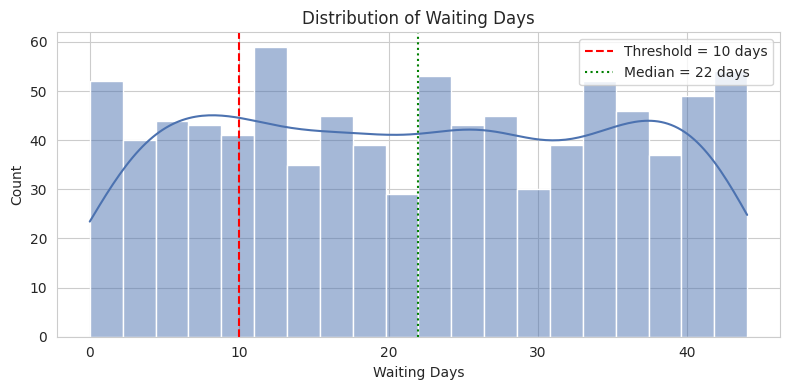

First quartile: 10.0 days
Median waiting time: 22.0 days
Records with waiting_days > 10: 74.9%


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_model['waiting_days'], bins=20, kde=True,
             ax=ax, color='#4C72B0')

median_wait = df_model['waiting_days'].median()
first_quartile = df_model['waiting_days'].quantile(0.25)
ax.axvline(10, color='red', linestyle='--', label='Threshold = 10 days')
ax.axvline(median_wait, color='green', linestyle=':',
           label=f'Median = {median_wait:.0f} days')
ax.set_title('Distribution of Waiting Days')
ax.set_xlabel('Waiting Days')
ax.legend()
plt.tight_layout()
plt.show()

print(f'First quartile: {first_quartile:.1f} days')
print(f'Median waiting time: {median_wait:.1f} days')
print(f'Records with waiting_days > 10: {(df_model["waiting_days"] > 10).mean():.1%}')

In [12]:
temp_flag = (df_model['waiting_days'] > 10).astype(int)
rate_by_flag = df_model.groupby(temp_flag)['no_show'].mean()

print('No-show rate, waiting_days <= 10:', round(rate_by_flag.loc[0], 3))
print('No-show rate, waiting_days > 10 :', round(rate_by_flag.loc[1], 3))
print('Rate difference:', round(rate_by_flag.loc[1] - rate_by_flag.loc[0], 3))

No-show rate, waiting_days <= 10: 0.423
No-show rate, waiting_days > 10 : 0.614
Rate difference: 0.191


**Observation:** Ten days is the first-quartile boundary of the corrected waiting-time distribution. The no-show rate is higher for appointments above this boundary.

**Justification:** The threshold provides an interpretable indicator of a longer wait relative to the shortest-wait group. It is not treated as a replacement for `waiting_days`; both variables are retained so the model can use the exact value and test whether the binary pattern provides additional information.

In [13]:
df_model['long_wait_flag'] = (df_model['waiting_days'] > 10).astype(int)

print('Shape after adding long_wait_flag:', df_model.shape)
display(df_model[['waiting_days','long_wait_flag','no_show']].head())

Shape after adding long_wait_flag: (875, 26)


,waiting_days,long_wait_flag,no_show
0,10,0,0
1,2,0,0
2,22,1,1
3,16,1,0
5,43,1,1


## 3.7 Feature Selection

In [14]:
target_association = (df_model.corr(numeric_only=True)['no_show']
                      .drop('no_show')
                      .sort_values(key=abs, ascending=False))
display(target_association.head(12).to_frame('Correlation with no_show'))

zero_variance = [c for c in df_model.columns
                 if c != 'no_show' and df_model[c].nunique() <= 1]
print('Zero-variance features:', zero_variance)

,Correlation with no_show
waiting_days,0.264758
long_wait_flag,0.167186
missed_ratio,0.088491
previous_appointments,-0.080247
age,-0.074934
missed_previous_appointments,0.071578
has_missed_before,0.059959
appointment_dayofweek,0.059657
diagnosis_Chest Pain,0.052415
department_Neurology,0.048343


Zero-variance features: []


**Observation:** `waiting_days` has the strongest individual association with the target. No zero-variance features remain. Several other features have weak individual correlations.

**Justification:** Features are not removed only because of weak linear correlation, because combined or non-linear relationships may still be useful. Final supervised feature selection is performed inside the Task 05 training pipeline to prevent information leakage.

## 3.8 Feature Scaling

In [15]:
scale_columns = ['age','waiting_days','previous_appointments',
                 'missed_previous_appointments','previous_admissions',
                 'appointment_month','appointment_dayofweek','missed_ratio']

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[scale_columns] = scaler.fit_transform(df_model[scale_columns])

**Justification:** Scaling prevents large numerical ranges from dominating distance- and margin-based models such as Logistic Regression and SVM. This scaled file demonstrates the required preprocessing step. During Task 05, scaling must be fitted again only on the training data inside a pipeline to prevent data leakage.

## 3.9 Save the Processed Datasets

In [16]:
assert df_model.shape == (875, 26)
assert df_model.isnull().sum().sum() == 0

df_model.to_csv('smartcare_preprocessed_unscaled.csv', index=False)
df_scaled.to_csv('smartcare_preprocessed_scaled.csv', index=False)

print('Unscaled dataset:', df_model.shape)
print('Scaled dataset:', df_scaled.shape)
print('Saved successfully.')

Unscaled dataset: (875, 26)
Scaled dataset: (875, 26)
Saved successfully.


### Task 03 Summary

The final datasets contain 875 confirmed appointments and 26 columns: 25 candidate input features and one target. Data leakage was removed, categorical variables were encoded, useful behavioural features were created, feature relevance was reviewed, and numerical variables were scaled. The unscaled version is used for EDA, while Task 05 should perform leakage-safe scaling inside its training pipeline.

# Task 04 - Exploratory Data Analysis

### Import libraries and load the Task 03 output

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('smartcare_preprocessed_unscaled.csv')
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (875, 26)


,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,no_show,appointment_month,appointment_dayofweek,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,missed_ratio,has_missed_before,long_wait_flag
0,53,10,1,0,1,0,4,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.000,0,0
1,26,2,3,1,0,0,5,3,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.250,1,0
2,22,22,7,1,1,1,7,2,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0.125,1,1
3,44,16,1,0,0,0,10,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0,1
4,50,43,1,0,0,1,10,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0.000,0,1


## 4.1 Descriptive Statistics

In [18]:
summary_columns = ['age','waiting_days','previous_appointments',
                   'missed_previous_appointments','previous_admissions',
                   'missed_ratio','no_show']
display(df[summary_columns].describe().round(2))

,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,missed_ratio,no_show
count,875.00,875.00,875.00,875.00,875.00,875.00,875.00
mean,44.78,22.00,2.86,0.57,0.85,0.15,0.57
std,17.71,13.12,1.68,0.75,0.95,0.21,0.50
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,33.50,10.00,2.00,0.00,0.00,0.00,0.00
50%,45.00,22.00,3.00,0.00,1.00,0.00,1.00
75%,57.00,34.00,4.00,1.00,1.00,0.25,1.00
max,90.00,44.00,10.00,4.00,5.00,1.00,1.00


**Insight:** The dataset contains 875 confirmed appointment outcomes. Waiting days range from 0 to 44, and the median is 22 days. The target mean shows that no-show appointments form a moderate majority.

## 4.2 Class Distribution Chart

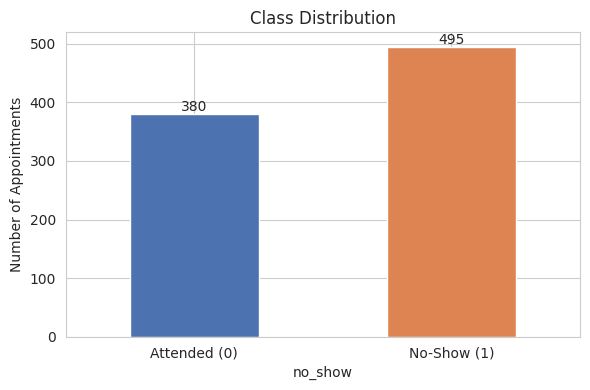

In [19]:
counts = df['no_show'].value_counts().sort_index()
ax = counts.plot(kind='bar', color=['#4C72B0','#DD8452'], figsize=(6,4))
ax.set_xticklabels(['Attended (0)','No-Show (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Number of Appointments')
for i, value in enumerate(counts):
    ax.text(i, value+5, str(value), ha='center')
plt.tight_layout()
plt.show()

**Insight:** The corrected dataset contains 380 attended appointments and 495 no-shows. The classes are moderately imbalanced, so Task 05 should report precision, recall, F1-score, and ROC-AUC instead of relying only on accuracy.

## 4.3 Histogram - Distribution Analysis

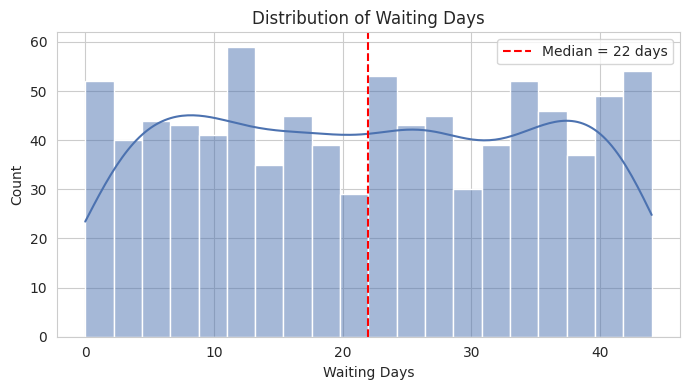

In [20]:
plt.figure(figsize=(7,4))
sns.histplot(df['waiting_days'], bins=20, kde=True, color='#4C72B0')
plt.axvline(df['waiting_days'].median(), color='red', linestyle='--',
            label=f"Median = {df['waiting_days'].median():.0f} days")
plt.title('Distribution of Waiting Days')
plt.xlabel('Waiting Days')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Waiting days are distributed across the full range. The median waiting time is 22 days, showing that the earlier 10-day flag is not a median split.

## 4.4 Boxplots - Outliers and Group Comparison

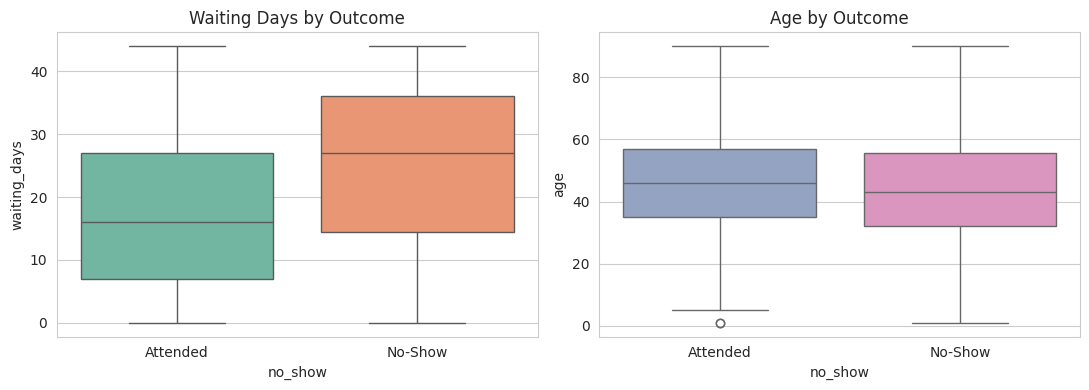

In [21]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=df, x='no_show', y='waiting_days', hue='no_show',
            palette=['#66C2A5','#FC8D62'], legend=False, ax=axes[0])
axes[0].set_xticks([0,1], ['Attended','No-Show'])
axes[0].set_title('Waiting Days by Outcome')

sns.boxplot(data=df, x='no_show', y='age', hue='no_show',
            palette=['#8DA0CB','#E78AC3'], legend=False, ax=axes[1])
axes[1].set_xticks([0,1], ['Attended','No-Show'])
axes[1].set_title('Age by Outcome')
plt.tight_layout()
plt.show()

**Insight:** The no-show group generally has a longer waiting period. Age distributions overlap strongly, so age alone is not a strong predictor of no-show behaviour.

## 4.5 Scatterplot - Relationship Analysis

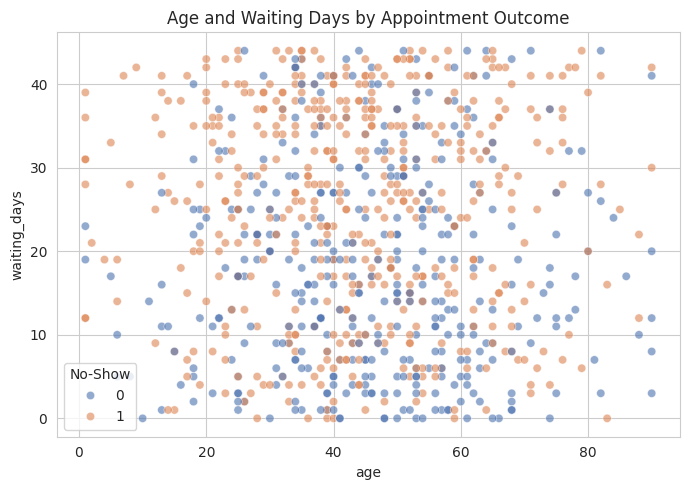

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='age', y='waiting_days',
                hue='no_show', alpha=0.6,
                palette=['#4C72B0','#DD8452'])
plt.title('Age and Waiting Days by Appointment Outcome')
plt.legend(title='No-Show')
plt.tight_layout()
plt.show()

**Insight:** Attended and no-show records overlap across age groups. No-shows appear more frequently at higher waiting times, confirming that waiting time provides more separation than age.

## 4.6 Correlation Heatmap

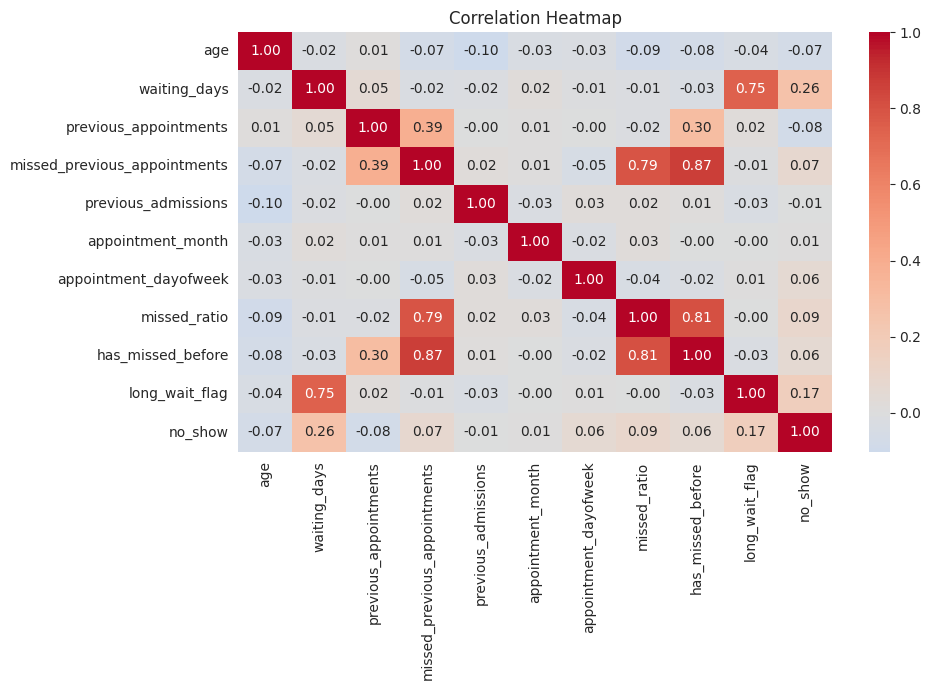

In [23]:
corr_columns = ['age','waiting_days','previous_appointments',
                'missed_previous_appointments','previous_admissions',
                'appointment_month','appointment_dayofweek','missed_ratio',
                'has_missed_before','long_wait_flag','no_show']

plt.figure(figsize=(10,7))
sns.heatmap(df[corr_columns].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:** `waiting_days` has the strongest positive correlation with no-show status. The remaining relationships are mostly weak. Correlation describes association, not causation, and weak correlation does not prove that a feature is useless in a multivariable model.

## 4.7 Pattern Discovery

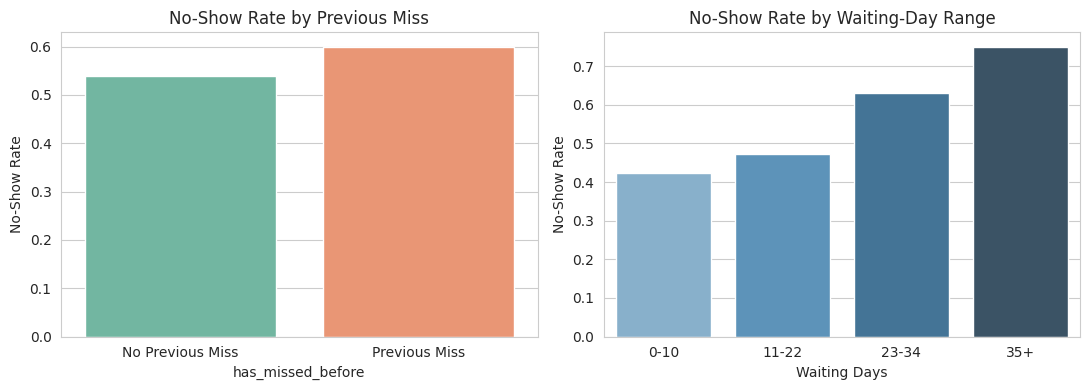

,has_missed_before,No-Show Rate
0,0,0.540
1,1,0.599


,Waiting_Range,No-Show Rate
0,0-10,0.423
1,11-22,0.472
2,23-34,0.631
3,35+,0.750


In [24]:
previous_miss_pattern = (df.groupby('has_missed_before')['no_show']
                         .mean().reset_index(name='No-Show Rate'))

# Waiting ranges are created only for EDA visualization; the model keeps exact waiting_days.
wait_ranges = pd.cut(df['waiting_days'], bins=[-1,10,22,34,np.inf],
                     labels=['0-10','11-22','23-34','35+'])
waiting_pattern = (df.assign(Waiting_Range=wait_ranges)
                   .groupby('Waiting_Range', observed=True)['no_show']
                   .mean().reset_index(name='No-Show Rate'))

fig, axes = plt.subplots(1,2,figsize=(11,4))
sns.barplot(data=previous_miss_pattern, x='has_missed_before', y='No-Show Rate',
            hue='has_missed_before', palette=['#66C2A5','#FC8D62'], legend=False, ax=axes[0])
axes[0].set_xticks([0,1], ['No Previous Miss','Previous Miss'])
axes[0].set_title('No-Show Rate by Previous Miss')

sns.barplot(data=waiting_pattern, x='Waiting_Range', y='No-Show Rate',
            hue='Waiting_Range', palette='Blues_d', legend=False, ax=axes[1])
axes[1].set_title('No-Show Rate by Waiting-Day Range')
axes[1].set_xlabel('Waiting Days')
plt.tight_layout()
plt.show()

display(previous_miss_pattern.round(3))
display(waiting_pattern.round(3))

**Insight:** Previous missed appointments and longer waiting periods are associated with higher no-show rates. These are descriptive patterns and should be tested through cross-validation during model development.

## 4.8 EDA Summary

- The corrected dataset contains 875 rows and 26 columns.
- The target has moderate class imbalance: 380 attended and 495 no-show appointments.
- Waiting days show the clearest relationship with no-show behaviour.
- Previous missed appointments provide additional behavioural information.
- Age and most other features have weak individual relationships.
- The results support multivariable model development, but they do not prove causal relationships.